In [19]:
import einops as eps
import torch
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from dataset import DexYCB
from utils import mano

In [2]:
dataset_train = DexYCB("s0", "train")
dataset_test = DexYCB("s0", "test")


In [4]:
%matplotlib inline

def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:,None,None] + mean[:,None,None]
    return img.permute(1,2,0)

# bx = 69

# train_sample = dataset_train[bx]
# test_sample =   dataset_test[bx]

# plt.subplot(1,2,1)
# plt.imshow(unnormalize(train_sample['image']))
# plt.subplot(1,2,2)
# plt.imshow(unnormalize(test_sample['image']))
# plt.show()

# import random

# bx = [random.randint(0, 1000) for _ in range(8)]  # 示例索引

# # 创建 4 行 2 列的子图
# fig, axs = plt.subplots(4, 2, figsize=(10, 20))

# for i, index in enumerate(bx):
#     train_sample = dataset_train[index]
#     test_sample = dataset_test[index]
    
#     # 显示训练集图像
#     axs[i, 0].imshow(unnormalize(train_sample['image']))
#     axs[i, 0].set_title(f'Train Image {index}')
#     axs[i, 0].axis('off')  # 关闭坐标轴

#     # 显示测试集图像
#     axs[i, 1].imshow(unnormalize(test_sample['image']))
#     axs[i, 1].set_title(f'Test Image {index}')
#     axs[i, 1].axis('off')  # 关闭坐标轴

# plt.tight_layout()  # 自动调整布局
# plt.show()

In [3]:
dataset = DexYCB("s0", "train")
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)

In [5]:
from tqdm import tqdm

data_iter = iter(dataloader)
for _ in tqdm(range(33), ncols=50):
    data_item = next(data_iter)

100%|█████████████| 33/33 [00:01<00:00, 20.29it/s]


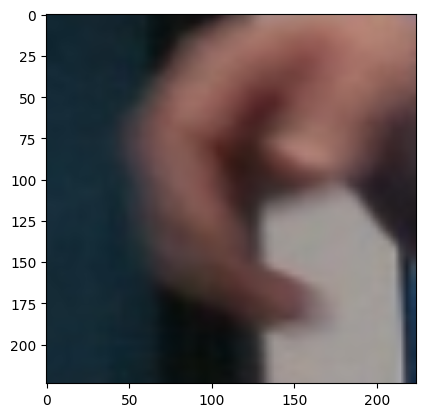

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

bx = 3

plt.clf()
image = data_item['image'][bx]
plt.imshow(unnormalize(image))
plt.show()

In [8]:
pose = data_item['pose'][bx:bx+1]
shape = data_item['shape'][bx:bx+1]

output_gt = mano.layer['right'](betas=shape,
                             hand_pose=pose[:,3:],
                             global_orient=pose[:,:3],
                             transl=torch.zeros(1,3))

In [14]:
import torch
import resnet

model: torch.nn.Module = resnet.pose_resnet50()
ckpt = torch.load("logs/23-20240930-2/checkpoint-10.pth", map_location="cpu", weights_only=False)
# logs/22-20240919-1/checkpoint-29.pth
model.load_state_dict(ckpt["model"])
model.to("cuda:5")
model.eval()
pass

trigger EVAL mode


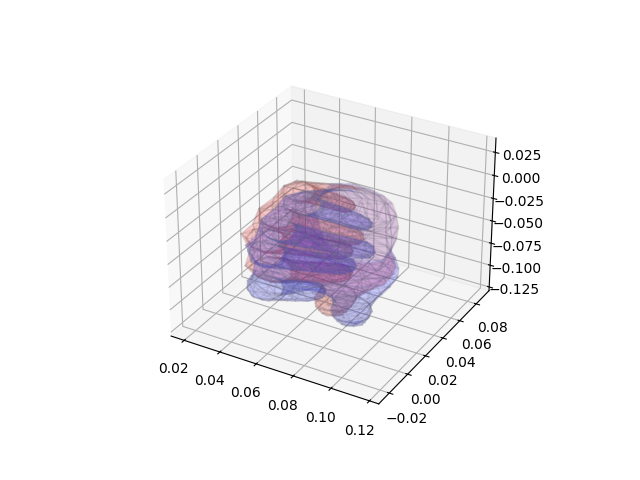

In [36]:
%matplotlib widget

with torch.no_grad():
    pose_pred = model(data_item["image"].to("cuda:5"))
    pose_pred = pose_pred[bx:bx+1].reshape(1,-1).to("cpu").detach()

pose = data_item['pose'][bx:bx+1]
shape = data_item['shape'][bx:bx+1]

output_gt = mano.layer['right'](betas=shape,
                             hand_pose=pose[:,3:],
                             global_orient=pose[:,:3],
                             transl=torch.zeros(1,3))
output_pred = mano.layer["right"](betas=shape,
                                  hand_pose=pose_pred[:,3:],
                                  global_orient=pose_pred[:,:3],
                                  transl=torch.zeros(1,3))

faces = mano.face['right']

verts_gt = output_gt.vertices[0].numpy()
verts_pred = output_pred.vertices[0].numpy()

mesh_gt = Poly3DCollection(verts_gt[faces], color='r', alpha=0.1, edgecolor='gray')
mesh_pred = Poly3DCollection(verts_pred[faces], color='b', alpha=0.1, edgecolor='gray')

plt.clf()
fig3d = plt.figure(3)
ax3d = fig3d.add_subplot(111, projection='3d')

ax3d.add_collection3d(mesh_gt)
ax3d.add_collection3d(mesh_pred)

plt.show()

In [52]:
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

def vis_mano(pose_gt, pose_pred, shape_gt, shape_pred, hand_type: str = 'right'):
    assert hand_type in ['right', 'left']
    output_gt = mano.layer[hand_type](betas=shape_gt,
                                      hand_pose=pose_gt[:,3:],
                                      global_orient=pose_gt[:,:3],
                                      transl=torch.zeros(1,3))
    output_pred = mano.layer[hand_type](betas=shape_pred,
                                        hand_pose=pose_pred[:,3:],
                                        global_orient=pose_pred[:,:3],
                                        transl=torch.zeros(1,3))
    faces = mano.face[hand_type]
    verts_gt = output_gt.vertices[0].numpy()
    verts_pred = output_pred.vertices[0].numpy()
    mesh_gt = Poly3DCollection(verts_gt[faces], color='r', alpha=0.1, edgecolor='gray')
    mesh_pred = Poly3DCollection(verts_pred[faces], color='b', alpha=0.1, edgecolor='gray')

    # 创建子图，2 个并排的 3D 图形
    fig, axs = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(10, 5))

    axs[0].add_collection3d(mesh_gt)
    axs[0].set_title('Ground Truth')
    scale_gt = verts_gt.flatten()
    axs[0].auto_scale_xyz(scale_gt, scale_gt, scale_gt)

    axs[1].add_collection3d(mesh_pred)
    axs[1].set_title('Prediction')
    scale_pred = verts_pred.flatten()
    axs[1].auto_scale_xyz(scale_pred, scale_pred, scale_pred)

    # 渲染图像并将其转换为 NumPy 数组
    canvas = FigureCanvas(fig)
    canvas.draw()

    # 获取图像尺寸并转换为 NumPy 数组
    img = np.frombuffer(canvas.tostring_rgb(), dtype='uint8')
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))

    plt.close(fig)  # 关闭图像，释放内存
    return img

In [53]:
%matplotlib inline

res = vis_mano(pose, pose_pred, shape, shape, 'right')
cv2.imwrite("out.png", res)

/tmp/ipykernel_35954/2498253184.py:37: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  img = np.frombuffer(canvas.tostring_rgb(), dtype='uint8')


True